In [1]:
#%pip install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import joblib
from torch.utils.data import TensorDataset, DataLoader

# ============================================================
# 1. Laden des Datensatzes
# ============================================================
df = pd.read_csv(r'D:\Python\dataset\digits.csv')
print(f"Datensatz: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
print(df.head())

Datensatz: 1797 Zeilen, 65 Spalten
   feature0  feature1  feature2  feature3  feature4  feature5  feature6  \
0       0.0       0.0       5.0      13.0       9.0       1.0       0.0   
1       0.0       0.0       0.0      12.0      13.0       5.0       0.0   
2       0.0       0.0       0.0       4.0      15.0      12.0       0.0   
3       0.0       0.0       7.0      15.0      13.0       1.0       0.0   
4       0.0       0.0       0.0       1.0      11.0       0.0       0.0   

   feature7  feature8  feature9  ...  feature55  feature56  feature57  \
0       0.0       0.0       0.0  ...        0.0        0.0        0.0   
1       0.0       0.0       0.0  ...        0.0        0.0        0.0   
2       0.0       0.0       0.0  ...        0.0        0.0        0.0   
3       0.0       0.0       8.0  ...        0.0        0.0        0.0   
4       0.0       0.0       0.0  ...        0.0        0.0        0.0   

   feature58  feature59  feature60  feature61  feature62  feature63  class 

In [3]:
# ============================================================
# 2. Features (X) und Target (y) trennen
# ============================================================
X = df.drop('class', axis=1).values    # 64 Pixel-Features
y = df['class'].values                  # Ziffern 0-9

# Klassen sind bereits 0-9 kodiert – kein LabelEncoder nötig
n_classes = len(np.unique(y))
print(f"Klassen:        {np.unique(y)}")
print(f"Anzahl Klassen: {n_classes}")
print(f"Klassenverteilung:\n{pd.Series(y).value_counts().sort_index()}")

Klassen:        [0 1 2 3 4 5 6 7 8 9]
Anzahl Klassen: 10
Klassenverteilung:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


In [4]:
# ============================================================
# 3. Train/Val/Test-Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
)

print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 1149  |  Val: 288  |  Test: 360


In [5]:
# ============================================================
# 4. Standardisierung (z-Score) der Features
# ============================================================
# WICHTIG: fit() nur auf Trainingsdaten, transform() auf alle Splits
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Train-Mittelwerte (soll ≈ 0):")
print(np.round(X_train.mean(axis=0)[:8], 4), "...")
print("Train-Std (soll ≈ 1):")
print(np.round(X_train.std(axis=0)[:8], 4), "...")

Train-Mittelwerte (soll ≈ 0):
[ 0.  0. -0.  0.  0.  0. -0.  0.] ...
Train-Std (soll ≈ 1):
[0. 1. 1. 1. 1. 1. 1. 1.] ...


In [6]:
# ============================================================
# 5. Umwandeln der Daten in PyTorch-Tensoren
# ============================================================
X_train_t = torch.from_numpy(X_train).float()
X_val_t   = torch.from_numpy(X_val).float()
X_test_t  = torch.from_numpy(X_test).float()
y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

In [7]:
# ============================================================
# 6. DataLoader für Batch-Verarbeitung
# ============================================================
train_dataset = TensorDataset(X_train_t, y_train_t)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [8]:
# ============================================================
# 7. Neuronales Netz definieren
# ============================================================
# 64 Pixel-Features → 32 → 10 Klassen
# BatchNorm stabilisiert das Training, Dropout verhindert Overfitting
n_features = X_train.shape[1]   # 64

net = nn.Sequential(
    nn.Linear(n_features, 32),
    nn.ReLU(),
#    nn.Dropout(0.3),
    nn.Linear(32, n_classes)
)
print(net)

Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=10, bias=True)
)


In [ ]:
# ============================================================
# 8. Training mit Batch-Verarbeitung
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=0.005)
#scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

losses_train = []
losses_val = []
n_epochs = 100

net.train()
for epoch in range(n_epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = net(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
       
    losses_train.append(loss.item())
    #scheduler.step()

    # Validierung nach jeder Epoche
    net.eval()
    with torch.no_grad():
        val_out  = net(X_val_t)
        val_loss = criterion(val_out, y_val_t)
        _, val_pred = torch.max(val_out, 1)
        val_acc = accuracy_score(y_val_t, val_pred)

        losses_val.append(val_loss.item())

    # Netzwerk wieder in Trainingsschritt versetzen, falls es nicht bereits im Modus ist.
    net.train()

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f'Epoch {epoch:3d} | Train-Loss: {loss.item():.4f} | Val-Loss: {val_loss.item():.4f} | Val-Acc: {val_acc:.4f}')

Epoch   0 | Train-Loss: 1.1268 | Val-Loss: 1.0352 | Val-Acc: 0.8090
Epoch  10 | Train-Loss: 0.0232 | Val-Loss: 0.1275 | Val-Acc: 0.9618
Epoch  19 | Train-Loss: 0.0041 | Val-Loss: 0.1118 | Val-Acc: 0.9653


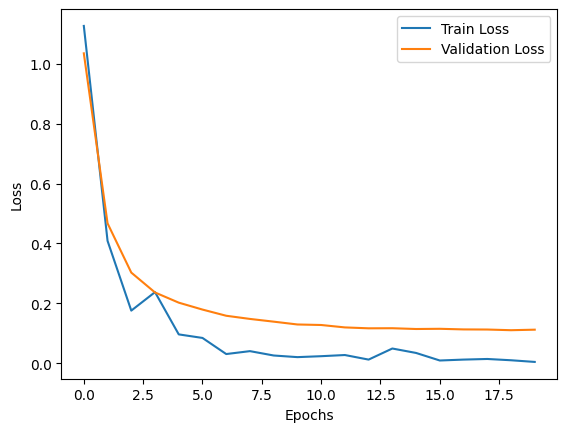

In [10]:
import matplotlib.pyplot as plt

# Loss-Plot
plt.plot(losses_train, label='Train Loss')
plt.plot(losses_val, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
# ============================================================
# 9. Evaluation auf Testdaten
# ============================================================
net.eval()
with torch.no_grad():
    outputs = net(X_test_t)
    _, predicted = torch.max(outputs, 1)
    accuracy = accuracy_score(y_test_t, predicted)
    print(f'Testgenauigkeit: {accuracy:.4f}')

Testgenauigkeit: 0.9694


In [12]:
# ============================================================
# 10. Modell und Scaler abspeichern
# ============================================================
torch.save(net.state_dict(), 'digits_net.pth')
joblib.dump(scaler, 'scaler_digits.pkl')
print("Gespeichert: digits_net.pth, scaler_digits.pkl")

Gespeichert: digits_net.pth, scaler_digits.pkl


In [13]:
# ============================================================
# 11. Wiederladen und Vorhersage (Inferenz)
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import numpy as np

scaler = joblib.load('scaler_digits.pkl')

net = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
#    nn.Dropout(0.3),
    nn.Linear(32, 10)
)
net.load_state_dict(torch.load('digits_net.pth', map_location='cpu'))
net.eval()

for k, v in net.named_parameters():
    print(k, v.shape)

0.weight torch.Size([32, 64])
0.bias torch.Size([32])
2.weight torch.Size([10, 32])
2.bias torch.Size([10])


In [14]:
# ============================================================
# 12. Einzelvorhersage – Beispiel aus dem Testset
# ============================================================
# Zufälligen Testfall auswählen (seed für Reproduzierbarkeit änderbar)
rng = np.random.default_rng(seed=42)
idx = rng.integers(0, len(X_test))

sample_raw    = X_test[idx]          # bereits skaliert (aus dem Split oben)
true_label    = y_test[idx]

# Für eine komplett neue Eingabe müsste man
# sample_raw = scaler.transform(np.array([<64 Rohwerte>])) verwenden
inputs_tensor = torch.tensor(sample_raw, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    output        = net(inputs_tensor)
    probabilities = F.softmax(output, dim=1)
    _, predicted  = torch.max(output, 1)

print(f"Wahrer Wert:              {true_label}")
print(f"Vorhergesagte Ziffer:     {predicted.item()}")
print(f"Klassenwahrscheinlichkeiten:")
for cls, prob in enumerate(probabilities.numpy()[0]):
    marker = " ← Vorhersage" if cls == predicted.item() else ""
    print(f"  Ziffer {cls}: {prob:.4f}{marker}")

Wahrer Wert:              2
Vorhergesagte Ziffer:     2
Klassenwahrscheinlichkeiten:
  Ziffer 0: 0.0000
  Ziffer 1: 0.0000
  Ziffer 2: 0.9860 ← Vorhersage
  Ziffer 3: 0.0047
  Ziffer 4: 0.0000
  Ziffer 5: 0.0000
  Ziffer 6: 0.0000
  Ziffer 7: 0.0000
  Ziffer 8: 0.0092
  Ziffer 9: 0.0000
